# GeneFormer

Geneformer is a foundational transformer model pretrained on a large-scale corpus of single cell transcriptomes to enable context-aware predictions in settings with limited data in network biology.

Here, you can use `omicverse.llm.SCLLMManager(model_type="geneformer")` to call this model directly.

Cite: Theodoris, C. V., Xiao, L., Chopra, A., Chaffin, M. D., Al Sayed, Z. R., Hill, M. C., ... & Ellinor, P. T. (2023). Transfer learning enables predictions in network biology. Nature, 618(7965), 616-624.

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load example datasets

For this tutorial, we use three batches from the NeurIPS 2021 single-cell competition dataset, which provides an excellent test case for batch integration and cell type annotation.

- s1d3: https://figshare.com/ndownloader/files/41932005
- s2d1: https://figshare.com/ndownloader/files/41932011
- s3d7: https://figshare.com/ndownloader/files/41932008

In [2]:
adata1=ov.read('data/neurips2021_s1d3.h5ad')
adata1.obs['batch']='s1d3'
adata2=ov.read('data/neurips2021_s2d1.h5ad')
adata2.obs['batch']='s2d1'
adata3=ov.read('data/neurips2021_s3d7.h5ad')
adata3.obs['batch']='s3d7'

In [3]:
adata=sc.concat([adata1,adata2,adata3],merge='same')
adata

AnnData object with n_obs × n_vars = 27423 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [4]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',
                       n_HVGs=3000,batch_key=None,target_sum=1e4)
adata

🔍 [2026-05-18 16:28:41] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 13953/13953 genes are kept.
    Among 13953 genes, 13953 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 9 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC', 'HBB', 'MALAT1', 'IGHA1', 'IGHM', 'HBA2', 'IGLC1', 'IGLC2', 'IGLC3']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 27,423 cells × 13,953 genes
   ✓ Runtime: 1.66s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 13,953 total (21.5%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 5.51 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

AnnData object with n_obs × n_vars = 27423 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'history_log', 'log1p', 'hvg', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [5]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata
# Geneformer V2 tokenizer custom_attr_dict requires this column.
adata.obs['cell_barcode'] = adata.obs_names.values


## Download pre-trained model and dictionaries

The Geneformer model requires several components:
1. **Model weights**: Pre-trained transformer parameters (~420MB)
2. **Gene dictionaries**: Mapping between genes and tokens
3. **Gene median values**: For rank-based encoding
4. **Ensembl mappings**: Gene symbol to ID conversions

Download from HuggingFace: https://huggingface.co/ctheodoris/Geneformer/tree/main/Geneformer-V2-104M

In [6]:
#!/usr/bin/env python3
import os
import requests

urls = [
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/Geneformer-V2-104M/model.safetensors?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/Geneformer-V2-104M/config.json?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/Geneformer-V2-104M/generation_config.json?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/Geneformer-V2-104M/training_args.bin?download=true",
    
]

output_dir = "llm_model/models/geneformer/Geneformer-V2-104M"
os.makedirs(output_dir, exist_ok=True)

for url in urls:
    filename = url.split('?')[0].split('/')[-1]
    filepath = os.path.join(output_dir, filename)
    
    print(f"Downloading {filename} ...")
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    with open(filepath, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print(f"Saved to {filepath}")

print("All files downloaded successfully.")


Saved to llm_model/models/geneformer/Geneformer-V2-104M/model.safetensors
Saved to llm_model/models/geneformer/Geneformer-V2-104M/config.json


Saved to llm_model/models/geneformer/Geneformer-V2-104M/generation_config.json


Saved to llm_model/models/geneformer/Geneformer-V2-104M/training_args.bin
All files downloaded successfully.


In [7]:
#!/usr/bin/env python3
import os
import requests

urls = [
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/geneformer/ensembl_mapping_dict_gc104M.pkl?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/geneformer/gene_median_dictionary_gc104M.pkl?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/geneformer/gene_name_id_dict_gc104M.pkl?download=true",
    "https://huggingface.co/ctheodoris/Geneformer/resolve/main/geneformer/token_dictionary_gc104M.pkl?download=true",
]

output_dir = "llm_model/models/geneformer"
os.makedirs(output_dir, exist_ok=True)

for url in urls:
    filename = url.split('?')[0].split('/')[-1]
    filepath = os.path.join(output_dir, filename)
    
    print(f"Downloading {filename} ...")
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    with open(filepath, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print(f"Saved to {filepath}")

print("All files downloaded successfully.")


Saved to llm_model/models/geneformer/ensembl_mapping_dict_gc104M.pkl
Saved to llm_model/models/geneformer/gene_median_dictionary_gc104M.pkl


Saved to llm_model/models/geneformer/gene_name_id_dict_gc104M.pkl
Saved to llm_model/models/geneformer/token_dictionary_gc104M.pkl
All files downloaded successfully.


## Initialize Geneformer V2 model

Geneformer V2 is the latest version with improved performance and a larger parameter count (104M). The model architecture is based on BERT with modifications for single-cell data.

In [8]:
manager = ov.llm.SCLLMManager(
    model_type='geneformer',
    model_version='V2',  
    device='cuda',
    
)
#analysis/omic_test/llm_model/Geneformer/geneformer/ensembl_mapping_dict_gc104M.pkl
manager.model.load_model(
    'llm_model/models/geneformer/Geneformer-V2-104M',
    gene_median_file='llm_model/models/geneformer/gene_median_dictionary_gc104M.pkl',
    token_dictionary_file='llm_model/models/geneformer/token_dictionary_gc104M.pkl',
    gene_mapping_file='llm_model/models/geneformer/ensembl_mapping_dict_gc104M.pkl'
)

INFO:datasets:JAX version 0.4.35 available.


[Loaded] Geneformer model initialized (version: V2)
[Loading] Loading Geneformer model
[Loaded] Tokenizer initialized with external dictionary files
[Loaded] Geneformer model loaded successfully


## Zero-shot embedding generation

Generate embeddings using the pre-trained Geneformer model. 

The resulting 768-dimensional embeddings capture cellular states based on gene expression patterns:

In [9]:
embeddings = manager.get_embeddings(adata,max_ncells=100000)

[🔬Cells] Data Summary:
    Cells: 27,423
    Genes: 3,000
    Batches: 3
      s3d7: 11,230 cells
      s2d1: 10,258 cells
      s1d3: 5,935 cells
[Embedding] Starting get_embeddings...
    cells: 27,423
    genes: 3,000
[Preprocessing] Preprocessing data for Geneformer...


[Loaded] Normalized total counts
[Preprocessing] Preprocessing completed: 27423 cells × 3000 genes
[Predicting] Extracting cell embeddings with Geneformer...
[Preprocessing] Converting data to Geneformer format
    [Preprocessing] Preparing data for Geneformer tokenization


    [Preprocessing] Adding ensembl_id column to adata.var
    [Warning] Using gene symbols as ensembl_id (may cause filtering)
        [ℹ️Info] Geneformer works best with Ensembl gene IDs
    [ℹ️Info] Gene mapping analysis:
    [Preprocessing] Proactive gene symbol mapping...


... storing 'batch' as categorical


    [Loaded] Successfully mapped 2767 genes to Ensembl IDs
    [Warning] Adding n_counts column to adata.obs...
    ✓ Added n_counts: mean=9915.1, std=42.4
    ✓ cell_barcode column already present


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at llm_model/models/geneformer/Geneformer-V2-104M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Training] Extracting embeddings...
    [Loaded] Using all 27423 cells (preserving order)


  0%|          | 0/138 [00:00<?, ?it/s]

[Loaded] Extracted embeddings from EmbExtractor: (27423, 768)


[✅Complete] get_embeddings completed successfully!
[✅Complete] Results summary:
    embedding_shape: (27423, 768)
    embedding_dim: 768


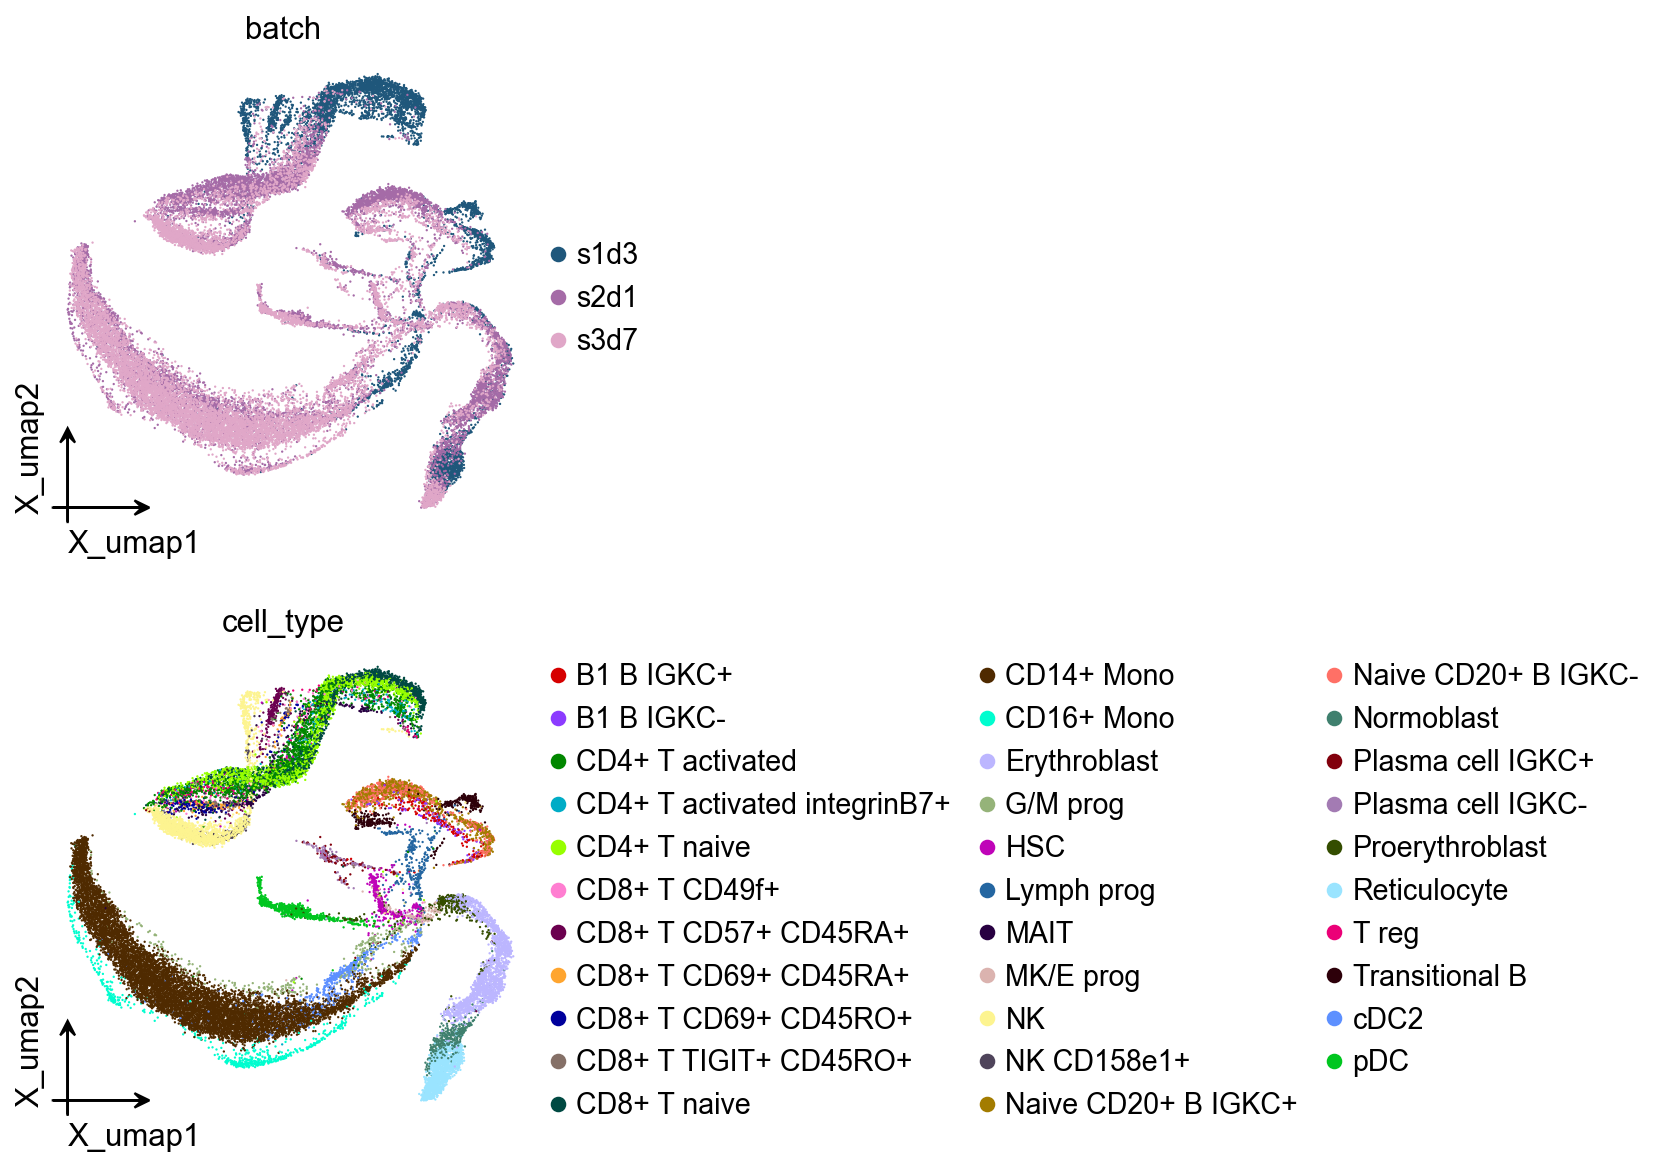

In [10]:
#adata.obsm['X_geneformer'] = df.loc[adata.obs.index,[f'emb_{i}' for i in range(0,768)]]
adata.obsm['X_geneformer'] = embeddings
sc.pp.neighbors(adata, use_rep='X_geneformer')
sc.tl.umap(adata)
ov.pl.embedding(
    adata, 
    basis='X_umap',
    color=['batch', 'cell_type']
)

## Fine-tuning for cell type classification

Fine-tune Geneformer on a reference dataset to adapt it for specific cell type recognition. The fine-tuning process updates the classification head while keeping most transformer layers frozen to prevent overfitting.


In [11]:
reference_adata=adata[adata.obs['batch']=='s1d3']

In [12]:
reference_adata

View of AnnData object with n_obs × n_vars = 5935 × 3000
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'cell_barcode'
    var: 'feature_types', 'gene_id', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'history_log', 'log1p', 'hvg', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'neighbors', 'umap', 'batch_colors_rgba', 'batch_colors', 'cell_type_colors_rgba', 'cell_type_colors'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_geneformer', 'X_umap'
    l

In [13]:
reference_adata.obs['celltype']=reference_adata.obs['cell_type'].copy()

In [14]:
fine_tune_results = manager.model.fine_tune(
    train_adata=reference_adata,
    epochs=10,           # 
    batch_size=32,       # 
    lr=1e-4,            # 
)

🔧 Fine-tuning Geneformer for annotation task...
Cell types detected: ['CD14+ Mono', 'CD8+ T naive', 'NK', 'T reg', 'CD8+ T CD57+ CD45RA+', 'Transitional B', 'Lymph prog', 'Naive CD20+ B IGKC+', 'Normoblast', 'Reticulocyte', 'CD4+ T naive', 'CD4+ T activated', 'CD8+ T TIGIT+ CD45RO+', 'B1 B IGKC+', 'CD4+ T activated integrinB7+', 'Erythroblast', 'MAIT', 'B1 B IGKC-', 'CD8+ T CD49f+', 'Naive CD20+ B IGKC-', 'G/M prog', 'Proerythroblast', 'HSC', 'CD16+ Mono', 'cDC2', 'CD8+ T CD69+ CD45RO+', 'pDC', 'CD8+ T CD69+ CD45RA+', 'Plasma cell IGKC+', 'MK/E prog']
[Preprocessing] Creating tokenized dataset
    [Preprocessing] Preparing data for Geneformer tokenization
    [Preprocessing] Adding ensembl_id column to adata.var
    [Warning] Using gene symbols as ensembl_id (may cause filtering)
        [ℹ️Info] Geneformer works best with Ensembl gene IDs
    [ℹ️Info] Gene mapping analysis:
    [Preprocessing] Proactive gene symbol mapping...


... storing 'batch' as categorical


    [Loaded] Successfully mapped 2767 genes to Ensembl IDs
    [Warning] Adding n_counts column to adata.obs...
    ✓ Added n_counts: mean=1028.9, std=375.6
    ✓ cell_barcode column already present
[Preprocessing] Tokenizing data for Geneformer
    [Preprocessing] Attempting real Geneformer tokenization...


/tmp/tmpmzd6x_nl/input/temp_data.h5ad has no column attribute 'filter_pass'; tokenizing all cells.


    [Loaded] Tokenized 5935 cells
Creating dataset.


    [Loaded] Tokenized 5935 cells
[Preprocessing] Adding labels and splitting dataset...
    Using cell_barcode mapping for labels...
    Train set: 5342 cells
    Eval set: 593 cells


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at llm_model/models/geneformer/Geneformer-V2-104M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    [Loaded] Model initialized with 30 classes
[Training] Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.836900,0.618931,0.841484,0.431948
2,0.438800,1.127026,0.757167,0.464733
3,0.660100,0.504429,0.848229,0.600986
4,0.391600,0.642319,0.779089,0.626923
5,0.216700,0.586425,0.851602,0.634323
6,0.211500,0.340056,0.908938,0.689735
7,0.160500,0.367801,0.871838,0.722647
8,0.095500,0.360919,0.910624,0.725895
9,0.117700,0.372868,0.903879,0.767029
10,0.052600,0.388586,0.905565,0.753861


[✅Complete] Fine-tuning completed
    [Loaded] Extracted BERT base model from classification model


### Batch integration with fine-tuned model

After fine-tuning, we perform batch integration to remove technical variations while preserving biological differences. This critical step ensures that cells from different batches can be properly compared and analyzed together.

In [15]:
zero_shot_results = manager.model.integrate(
    adata,
    batch_key="batch",
    correction_method="mnn",
    max_ncells=100000
)
adata.obsm['X_geneformer_fine'] = zero_shot_results['embeddings']

[Preprocessing] Performing batch integration with Geneformer embeddings...
[🔬Cells] Data Summary:
    Cells: 27,423
    Genes: 3,000
    Batches: 3
      s3d7: 11,230 cells
      s2d1: 10,258 cells
      s1d3: 5,935 cells
[Embedding] Starting get_embeddings...
    cells: 27,423
    genes: 3,000
[Preprocessing] Preprocessing data for Geneformer...


[Loaded] Normalized total counts
[Preprocessing] Preprocessing completed: 27423 cells × 3000 genes
[Predicting] Extracting cell embeddings with Geneformer...
[Preprocessing] Converting data to Geneformer format
    [Preprocessing] Preparing data for Geneformer tokenization


    [Preprocessing] Adding ensembl_id column to adata.var
    [Warning] Using gene symbols as ensembl_id (may cause filtering)
        [ℹ️Info] Geneformer works best with Ensembl gene IDs
    [ℹ️Info] Gene mapping analysis:
    [Preprocessing] Proactive gene symbol mapping...


... storing 'batch' as categorical


    [Loaded] Successfully mapped 2767 genes to Ensembl IDs
    [Warning] Adding n_counts column to adata.obs...
    ✓ Added n_counts: mean=9915.1, std=42.4
    ✓ cell_barcode column already present


...

    [Loaded] Tokenized 27423 cells
Creating dataset.


[Training] Extracting embeddings...
    [Loaded] Using all 27423 cells (preserving order)


  0%|          | 0/138 [00:00<?, ?it/s]

[Loaded] Extracted embeddings from EmbExtractor: (27423, 768)


[✅Complete] get_embeddings completed successfully!
[✅Complete] Results summary:
    embedding_shape: (27423, 768)
    embedding_dim: 768
    Found 3 batches with distribution: [ 5935 10258 11230]
    Using raw Geneformer embeddings
[Loaded] Integration completed using mnn method


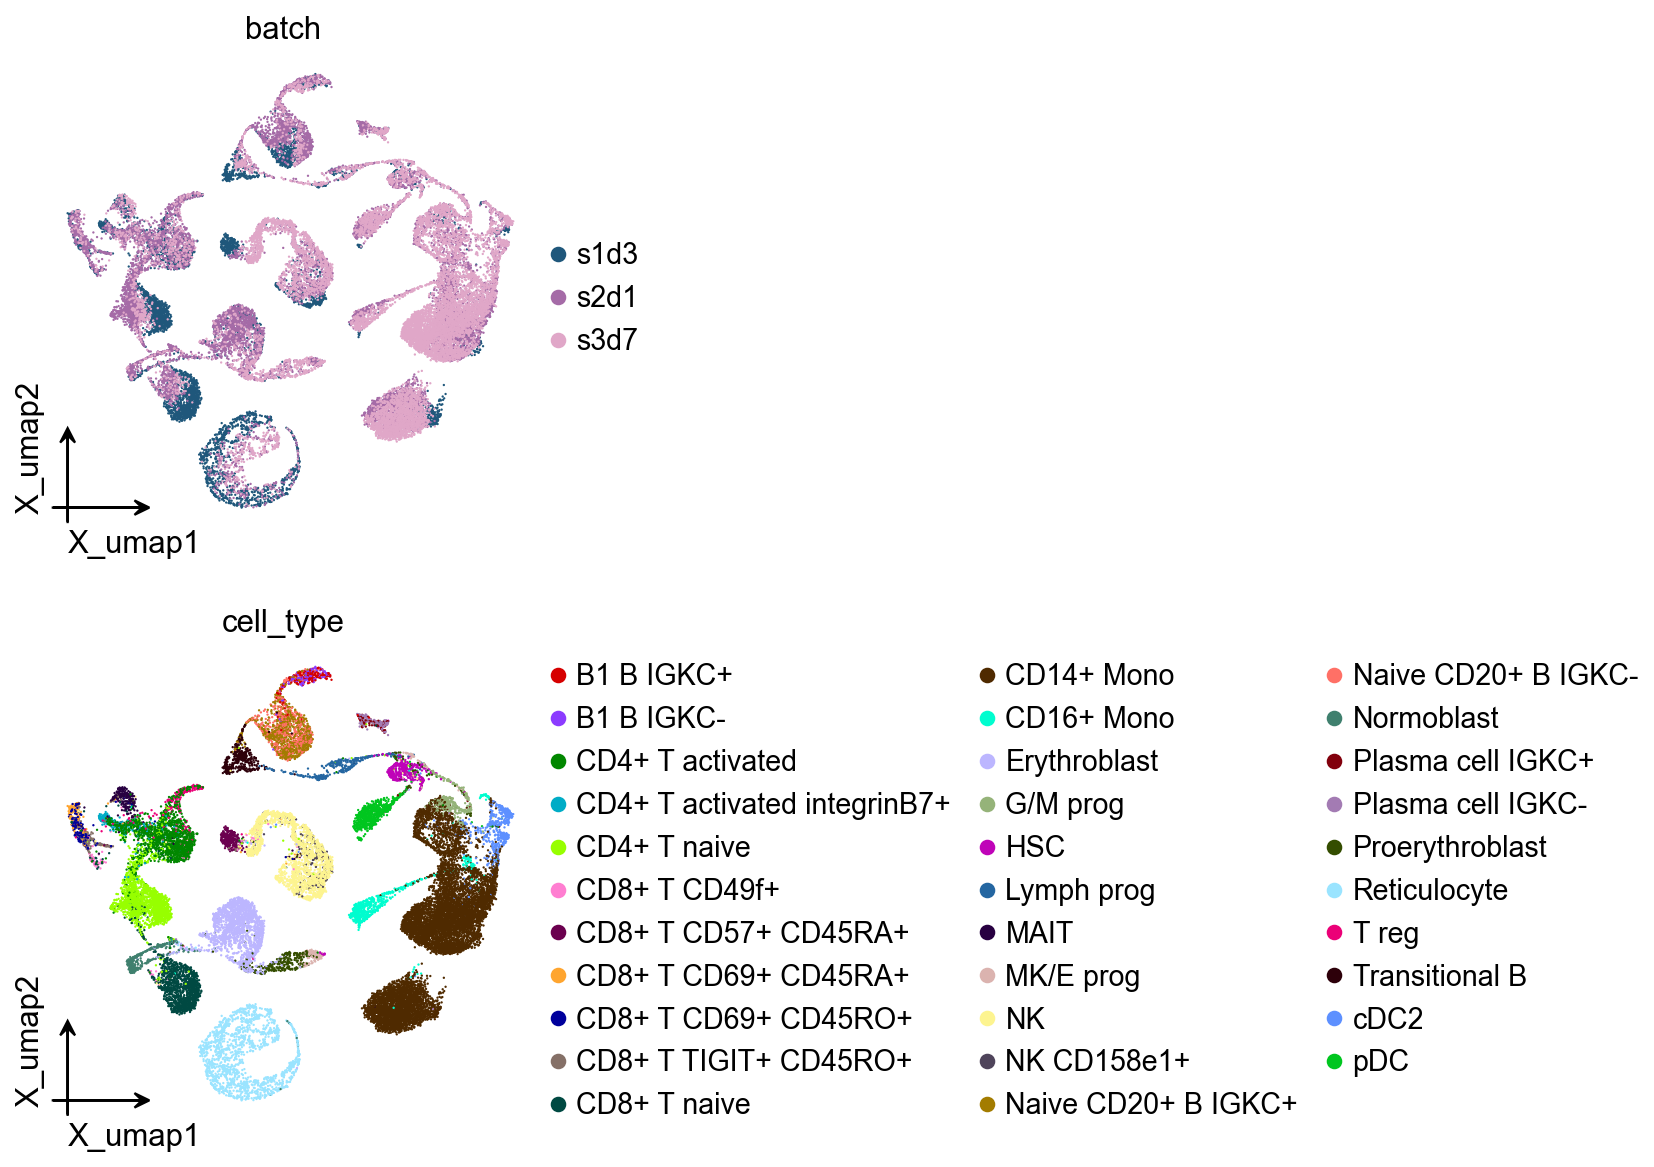

In [16]:
sc.pp.neighbors(adata, use_rep='X_geneformer_fine')
sc.tl.umap(adata)
ov.pl.embedding(
    adata, 
    basis='X_umap',
    color=['batch', 'cell_type']
)

### Cell type annotation with fine-tuned model

The fine-tuned GeneFormer model can now predict cell types for all cells in the dataset, including those from batches not used in training. This demonstrates the model's ability to generalize learned patterns to new data while leveraging the improved discrimination capability gained through fine-tuning.

In [17]:
results_anno = manager.model.predict(
    adata,
    task="annotation",
    max_ncells=100000
)

[Preprocessing] Preprocessing data for Geneformer...


[Loaded] Normalized total counts
[Preprocessing] Preprocessing completed: 27423 cells × 3000 genes
[Predicting] Predicting cell types with Geneformer...
[Preprocessing] Preparing data for prediction
    [Preprocessing] Preparing data for Geneformer tokenization


    [Preprocessing] Adding ensembl_id column to adata.var
    [Warning] Using gene symbols as ensembl_id (may cause filtering)
        [ℹ️Info] Geneformer works best with Ensembl gene IDs
    [ℹ️Info] Gene mapping analysis:
    [Preprocessing] Proactive gene symbol mapping...


... storing 'batch' as categorical


    [Loaded] Successfully mapped 2767 genes to Ensembl IDs
    [Warning] Adding n_counts column to adata.obs...
    ✓ Added n_counts: mean=9915.1, std=42.4
    ✓ cell_barcode column already present


[Preprocessing] Tokenizing data for Geneformer
    [Preprocessing] Attempting real Geneformer tokenization...


/tmp/tmph3e62akn/input/temp_data.h5ad has no column attribute 'filter_pass'; tokenizing all cells.


    [Loaded] Tokenized 27423 cells
Creating dataset.


    [Loaded] Tokenized 27423 cells for prediction
[Training] Running cell type prediction...


    [Loaded] Predicted 27423 cells


In [18]:
adata.obs['predicted_celltype'] = results_anno['predicted_celltypes']
adata.obs['predicted_celltype_id'] = results_anno['predictions']

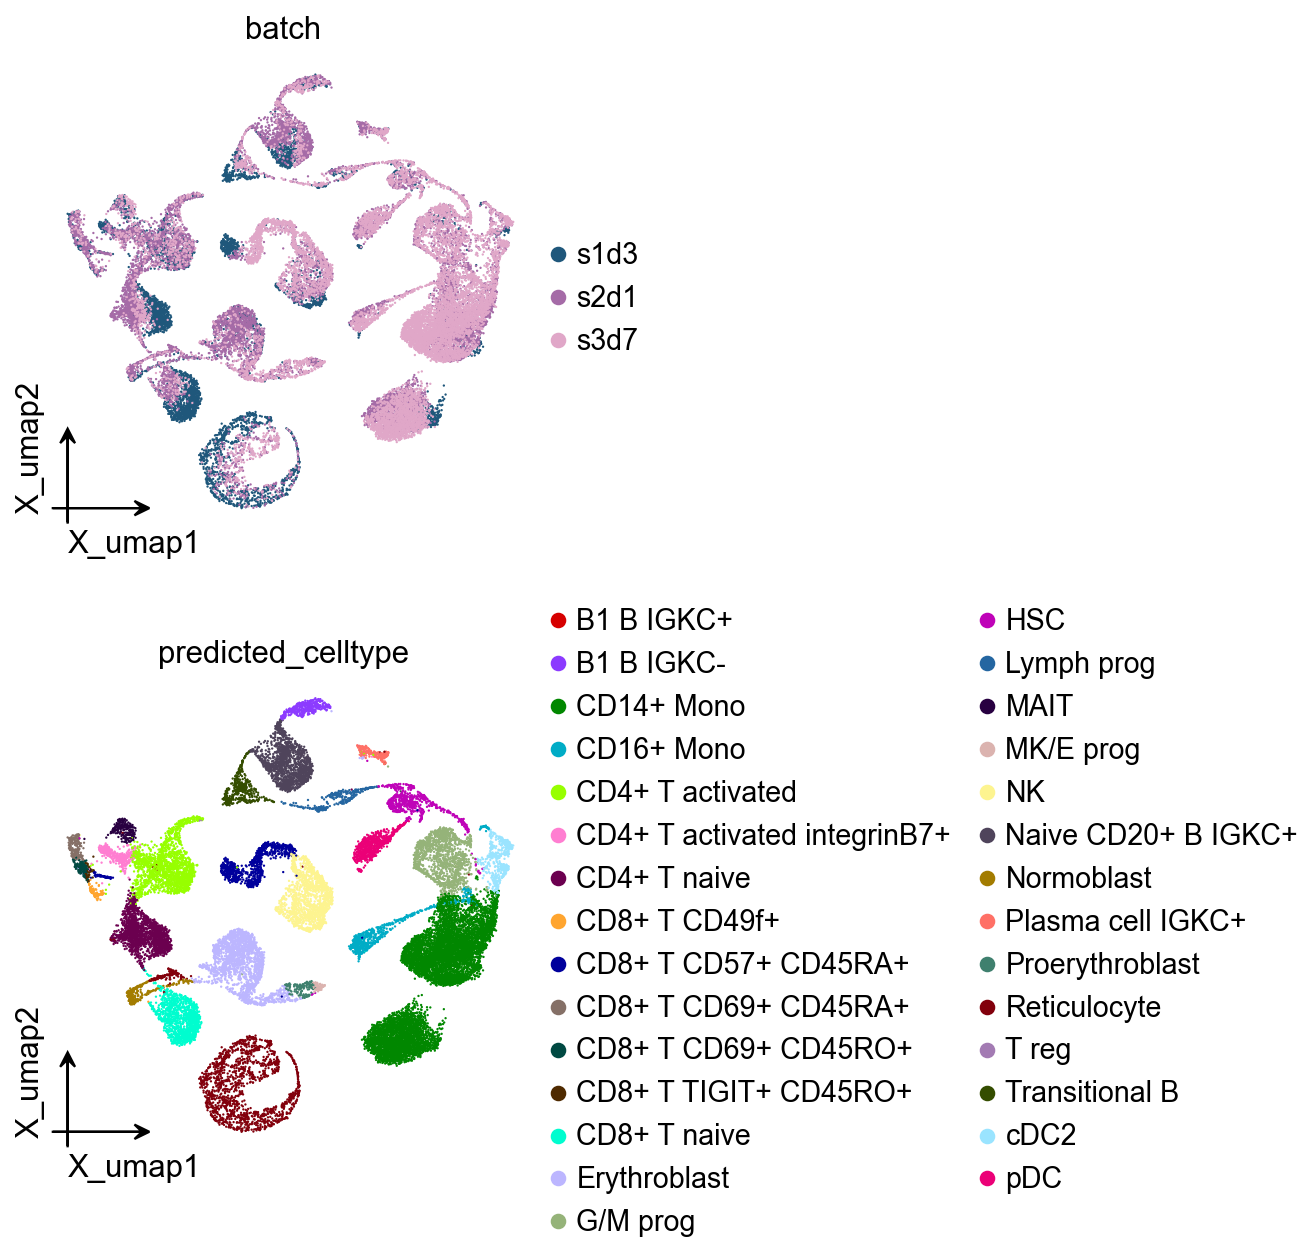

In [19]:
ov.pl.embedding(
    adata, 
    basis='X_umap',
    color=['batch', 'predicted_celltype']
)

## In-silico transcription-factor knockout

We can use Geneformer to ask: **what does the model predict will happen
if a transcription factor (TF) is deleted from a cell's
rank-value-encoded transcriptome?** Two complementary outputs:

1. **Cell-level cosine similarity** $\cos(e_i^{(0)}, e_i^{(g)})$ between
   the baseline and TF-deleted cell embedding. Absolute values are
   close to 1.0 (a single rank-token deletion is a small structural
   perturbation), but the **distribution** — especially its tail —
   reveals which cells are most context-sensitive to the TF.

2. **Per-gene downstream shift** $1 - \cos(e_g^{(0)}, e_g^{(\mathrm{TF})})$
   for every gene $g$ that co-occurs with the TF in a cell. Ranking
   genes by mean shift across cells gives a list of model-predicted
   downstream regulatory targets — this is the **primary biological
   output** of the perturbation analysis, not the raw cell-level
   numbers.

We pick three TFs covering distinct lineages in the bone-marrow dataset:

| TF | Lineage |
|---|---|
| `SPI1`  (PU.1)  | myeloid / B-cell |
| `PAX5`          | B-cell |
| `TBX21` (T-bet) | T-cell |

`GATA1` (the canonical erythroid master TF) gets filtered out by HVG
selection on this dataset, so we use these three instead.


In [21]:
# Stratified subset so each cell-type contributes ~equally and the rare
# lineages (B cells, NK cells, ...) carry enough of the perturbed cells
# to give a stable downstream-gene ranking.
import numpy as np
target_per_type = 100
rng = np.random.default_rng(0)
keep_idx = []
for ct, idx in adata.obs.groupby('cell_type').groups.items():
    pick = rng.choice(idx, min(target_per_type, len(idx)), replace=False)
    keep_idx.extend(pick)
adata_pert = adata[keep_idx].copy()
adata_pert.obs['cell_barcode'] = adata_pert.obs_names.values
adata_pert.obs['n_counts'] = np.asarray(adata_pert.X.sum(axis=1)).flatten()
print(f'subset shape: {adata_pert.shape}')


subset shape: (3200, 3000)


In [22]:
# Run the in-silico knockout. `compute_gene_shifts=True` (default) extracts
# per-token embeddings so we can also rank downstream genes per TF.
perturb_result = manager.model.perturb_genes(
    adata_pert,
    target_genes=['SPI1', 'PAX5', 'TBX21'],
    perturb_type='delete',
    max_ncells=adata_pert.n_obs,   # use the whole stratified subset
    forward_batch_size=50,
)


[Preprocessing] Preprocessing data for Geneformer...
[Loaded] Normalized total counts
[Preprocessing] Preprocessing completed: 3200 cells × 3000 genes
[Predicting] Geneformer in-silico delete of 3 gene(s) on 3200 cells


... storing 'batch' as categorical


... storing 'predicted_celltype' as categorical


Tokenizing /tmp/tmpku8iu1pm/input.h5ad
/tmp/tmpku8iu1pm/input.h5ad has no column attribute 'filter_pass'; tokenizing all cells.


Creating dataset.


...

    [ℹ️Info] Perturbing PAX5 (ENSG00000196092, token 16114)


  0%|          | 0/64 [00:00<?, ?it/s]

    [ℹ️Info] Perturbing TBX21 (ENSG00000073861, token 1241)


  0%|          | 0/64 [00:00<?, ?it/s]

    [ℹ️Info] Perturbation complete — see stats / cosine_similarities / gene_shifts


In [23]:
# Per-TF summary stats. `n_cells_perturbed` is the count of cells where
# the TF actually appeared in the rank-encoded input — only those cells
# contribute to the cosine + downstream-gene metrics.
perturb_result['stats']


,ensembl_id,token_id,n_cells_perturbed,n_cells_total,cosine_mean,cosine_std,cosine_min,n_downstream_genes_scored
gene,,,,,,,,
SPI1,ENSG00000066336,968,522,3200,0.998934,0.005628,0.901535,2552
PAX5,ENSG00000196092,16114,288,3200,0.997734,0.008817,0.887537,2335
TBX21,ENSG00000073861,1241,144,3200,0.994245,0.036458,0.564916,2193


### Cell-level cosine similarity

The bulk of values is near 1.0 because deleting one token from a
~2 000-token sequence is structurally a small change. What matters is
the **tail** — cells whose context Geneformer thinks shifts the most
under each knockout. PAX5 has the heaviest left tail; SPI1 / TBX21 are
tighter.


(<Figure size 480x280 with 1 Axes>,
 <Axes: title={'center': 'Geneformer in-silico delete — TF panel'}, xlabel='Perturbed gene', ylabel='Cosine similarity\n(original ↔ perturbed)'>)

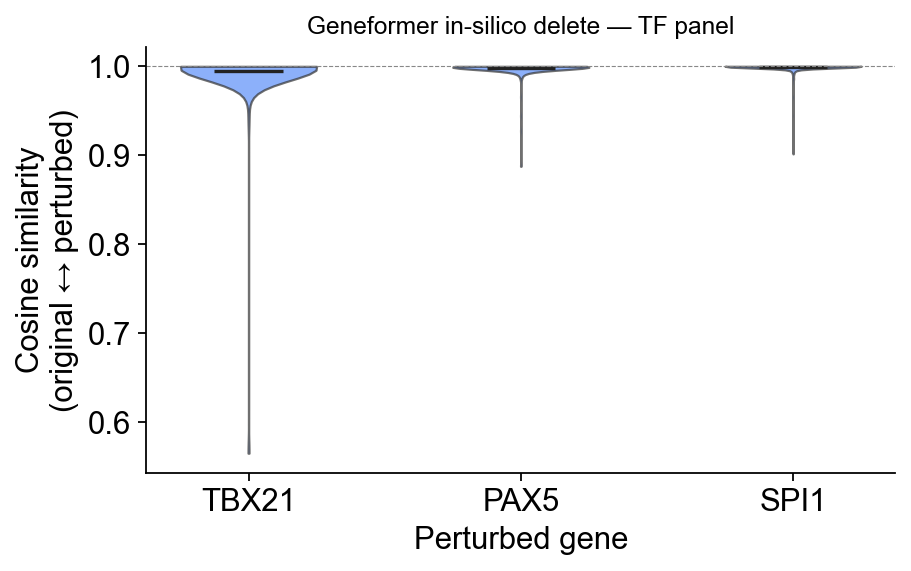

In [24]:
ov.pl.perturbation_shift_violin(perturb_result,
                                title='Geneformer in-silico delete — TF panel')


### Lineage specificity

Splitting each TF's violin by `cell_type` reveals which lineages are
most context-sensitive. For each gene the plot shows the top
~6 cell-types ranked by `|1 - cosine|`, so the legend stays readable
even on a 29-cell-type dataset.


(<Figure size 720x360 with 1 Axes>,
 <Axes: title={'center': 'Geneformer in-silico delete — by cell_type'}, xlabel='Perturbed gene', ylabel='Cosine similarity\n(original ↔ perturbed)'>)

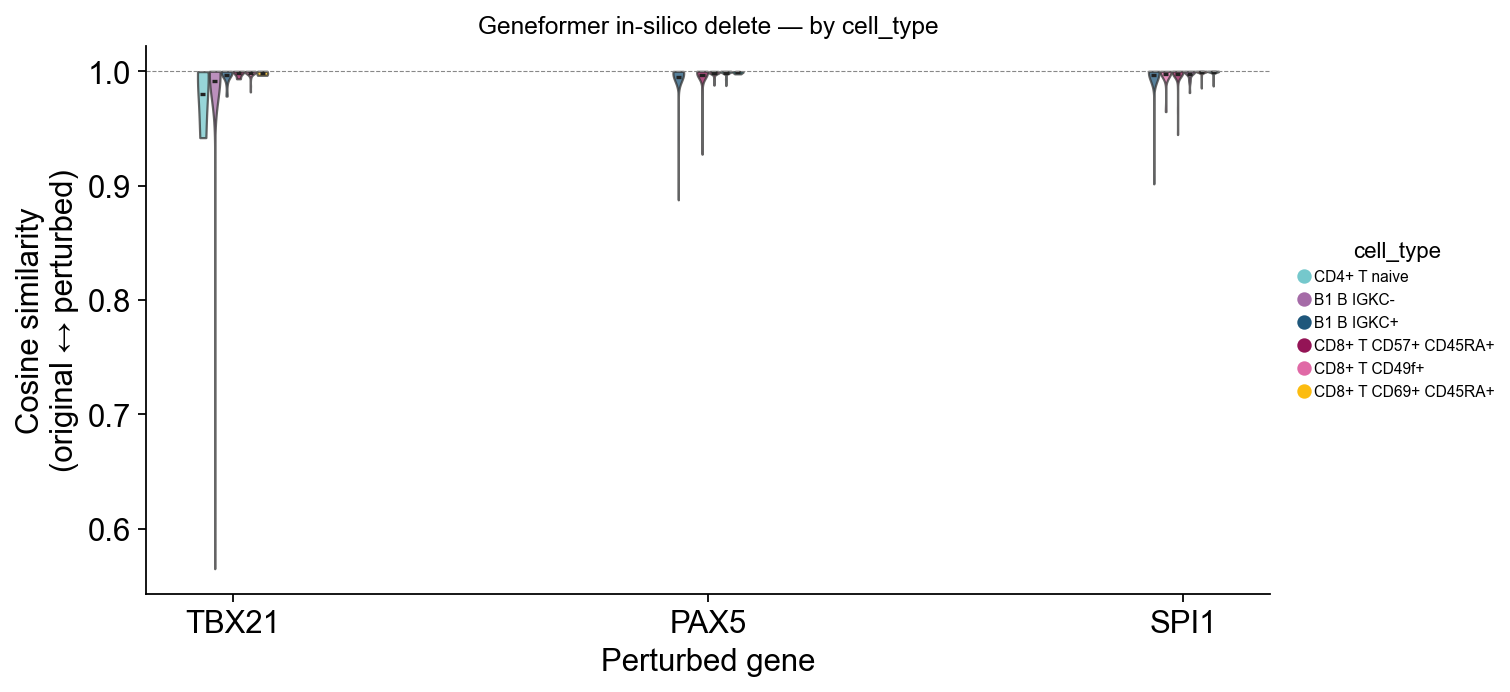

In [25]:
ov.pl.perturbation_shift_violin(perturb_result, adata=adata_pert,
                                groupby='cell_type', figsize=(9, 4.5))


### Top downstream genes — the biological signal

For each TF, rank all co-occurring genes by their per-gene embedding
shift. Larger shift = the model predicts that gene's contextual role
changes most when the TF is deleted = candidate downstream target.

Notice **TBX21** (the antagonistic T-cell TF) appearing in PAX5's
downstream list — consistent with the known PAX5↔TBX21 cross-lineage
repression.


(<Figure size 520x400 with 1 Axes>,
 <Axes: title={'center': 'Top 20 downstream genes shifted by delete of PAX5'}, xlabel='Mean 1 − cos(orig, perturbed)\n(higher = more shifted)', ylabel='Downstream gene'>)

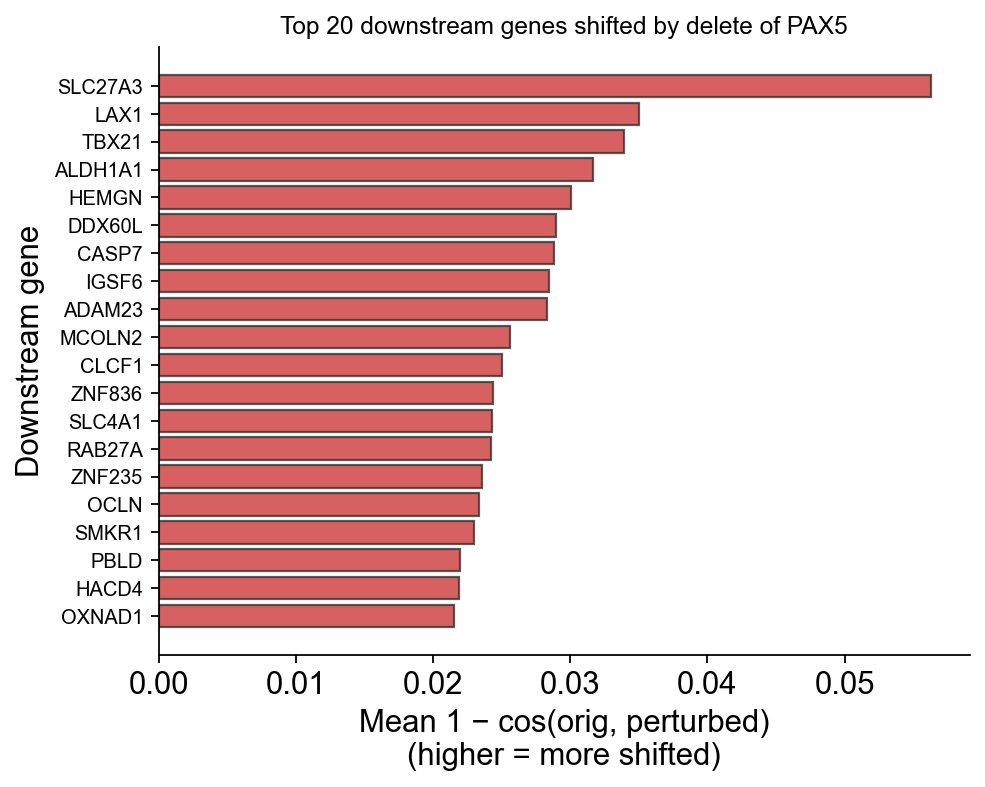

In [26]:
ov.pl.perturbation_top_downstream_genes(perturb_result, gene='PAX5', top_n=20)


(<Figure size 520x400 with 1 Axes>,
 <Axes: title={'center': 'Top 20 downstream genes shifted by delete of TBX21'}, xlabel='Mean 1 − cos(orig, perturbed)\n(higher = more shifted)', ylabel='Downstream gene'>)

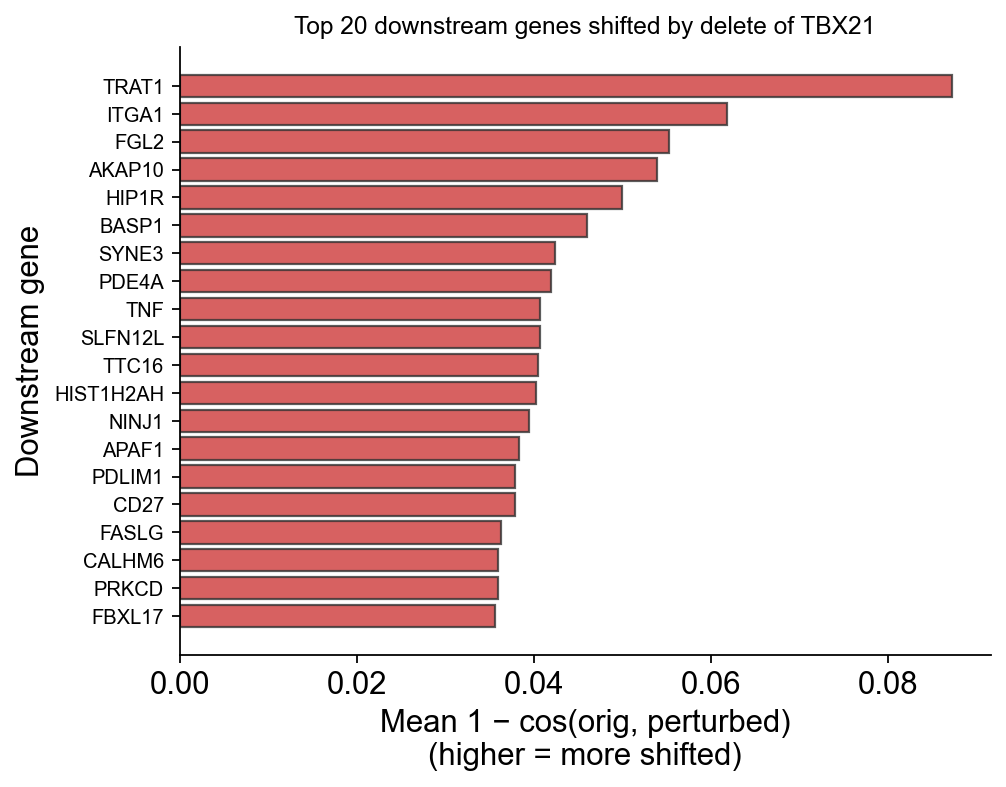

In [27]:
ov.pl.perturbation_top_downstream_genes(perturb_result, gene='TBX21', top_n=20)


(<Figure size 520x400 with 1 Axes>,
 <Axes: title={'center': 'Top 20 downstream genes shifted by delete of SPI1'}, xlabel='Mean 1 − cos(orig, perturbed)\n(higher = more shifted)', ylabel='Downstream gene'>)

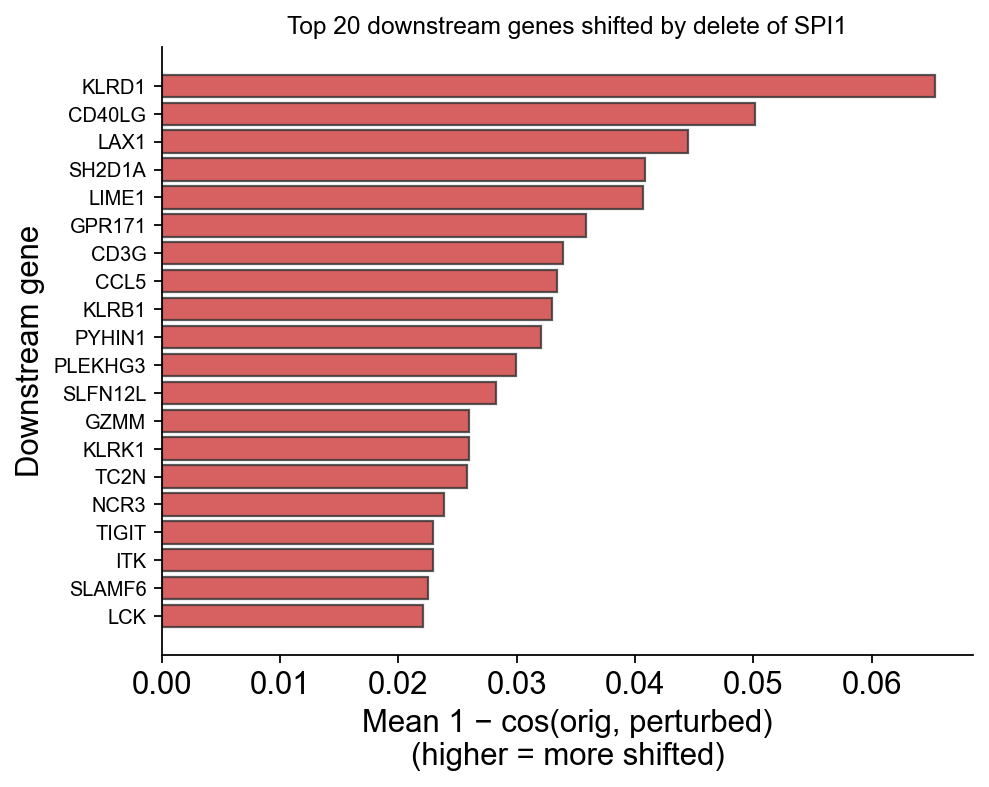

In [28]:
ov.pl.perturbation_top_downstream_genes(perturb_result, gene='SPI1', top_n=20)


---

**Want UMAP arrow plots of cell-state shifts?** `ov.pl.perturbation_embedding_shift(adata_pert, perturb_result, gene='PAX5', basis='X_umap', color='cell_type', max_arrows=200)` projects each cell's (original, perturbed) embedding pair onto an existing 2-D basis via least-squares and draws an arrow per cell. Requires `adata_pert.obsm['X_umap']` to already be computed — e.g. by running `sc.pp.neighbors` + `sc.tl.umap` on `adata_pert.obsm['X_geneformer_fine']` first.
